In [ ]:
from ultralytics import YOLO
import cv2
from IPython.display import clear_output, display
from PIL import Image

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
thickness = 2

model = YOLO('yolov8n.pt') 
names = model.model.names
print(names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light',
  10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep',
    19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie',
      28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove',
        36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife',
          44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog',
            53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet',
              62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microwave', 69: 'oven',
                70: 'toaster', 71: 'sink', 72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors', 77: 'teddy bear',
                    78: 'hair drier', 79: 'toothbrush'}

cap = cv2.VideoCapture(r"C:\Users\A45\Desktop\New folder\Cars Moving On Road Stock Footage - Free Download.mp4")

while cap.isOpened():

    success, frame = cap.read()
    if not success:
        print("Video frame is empty or video processing has been successfully completed.")
        break

    
    results = model.predict(frame , show=False,verbose = False)[0] 

    if results.boxes is not None and len(results.boxes) > 0:

        boxes = results.boxes.xyxy.cpu()
        clss = results.boxes.cls.int().cpu().tolist()
        confs = results.boxes.conf.cpu().tolist()

        for box, conf, cls_id in zip(boxes, confs, clss):
            x1, y1, x2, y2 = map(int, box.tolist())

            label = f"{names[cls_id]} | {conf:.2f}"

            # Draw bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

            # Draw label
            cv2.putText(frame, label, (x1, y1 - 10),
                        font, font_scale, (255, 0, 0), thickness)
            
            #save the output video
            
            
    # Display the frame
    clear_output(wait=True)
    display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

cap.release()

KeyboardInterrupt: 

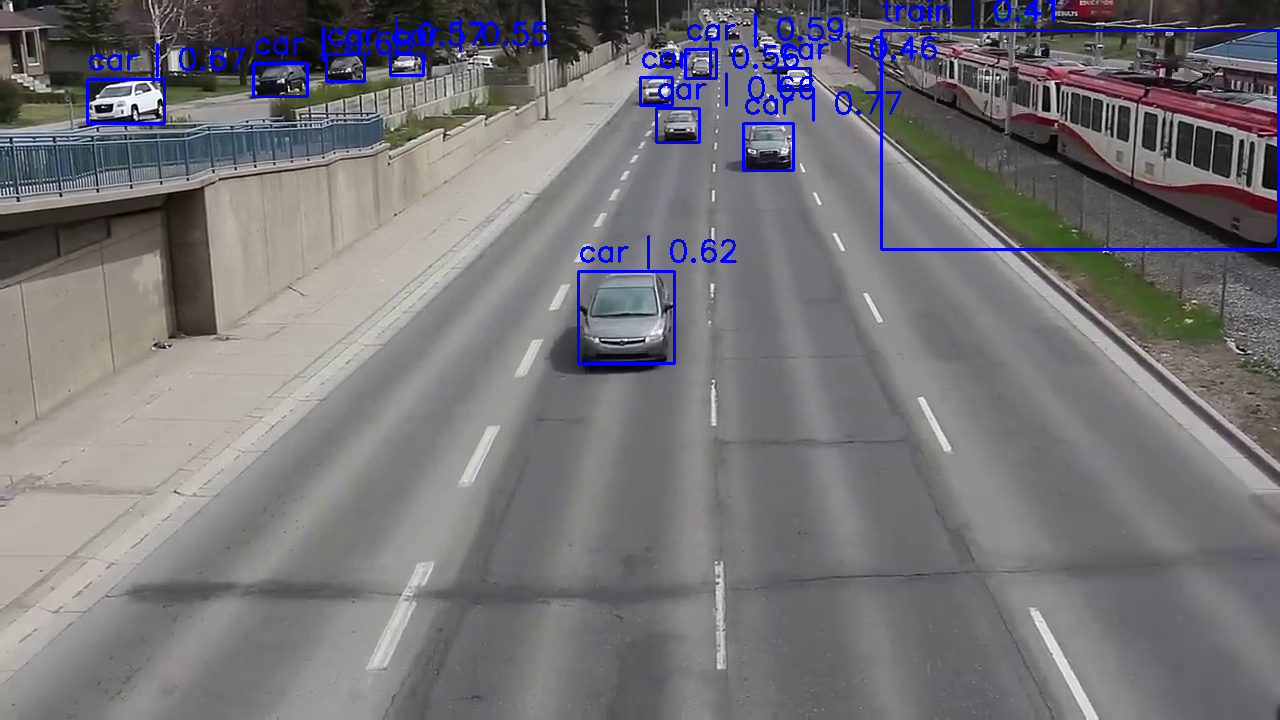

Video processing completed.
Video saved successfully!


In [3]:
from ultralytics import YOLO
import cv2
from IPython.display import clear_output, display
from PIL import Image

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
thickness = 2

model = YOLO('yolov8n.pt') 
names = model.model.names

# Read video
cap = cv2.VideoCapture(
    r"D:\Projects\car_detect\Cars Moving On Road Stock Footage - Free Download.mp4"
)

# =========================
# Video Writer Setup
# =========================

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    r"D:\Projects\car_detect\out Cars Moving On Road Stock Footage - Free Download.mp4",
    fourcc,
    fps,
    (width, height)
)

# =========================

while cap.isOpened():

    success, frame = cap.read()

    if not success:
        print("Video processing completed.")
        break

    results = model.predict(frame, show=False, verbose=False)[0]

    if results.boxes is not None and len(results.boxes) > 0:

        boxes = results.boxes.xyxy.cpu()
        clss = results.boxes.cls.int().cpu().tolist()
        confs = results.boxes.conf.cpu().tolist()

        for box, conf, cls_id in zip(boxes, confs, clss):

            x1, y1, x2, y2 = map(int, box.tolist())

            label = f"{names[cls_id]} | {conf:.2f}"

            # Draw Bounding Box
            cv2.rectangle(frame, (x1, y1), (x2, y2),
                          (255, 0, 0), 2)

            # Draw Label
            cv2.putText(frame, label, (x1, y1 - 10),
                        font, font_scale, (255, 0, 0), thickness)

    # =========================
    # Save Frame
    # =========================
    out.write(frame)

    # Display Frame
    clear_output(wait=True)
    display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

# Release
cap.release()
out.release()



print("Video saved successfully!")

In [8]:
from ultralytics import YOLO
import cv2
import time
import math



model = YOLO("yolov8n.pt")



cap = cv2.VideoCapture(
    r"D:\Projects\car_detect\Cars Moving On Road Stock Footage - Free Download.mp4"
)



width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    r"D:\Projects\car_detect\speed_output.mp4",
    fourcc,
    fps,
    (width, height)
)



line1_y = 250
line2_y = 400

distance_meters = 10  



car_times = {}
car_speeds = {}
car_id = 0


while True:

    success, frame = cap.read()

    if not success:
        break

    results = model(frame, verbose=False)[0]

    # Draw Lines
    cv2.line(frame, (0, line1_y), (width, line1_y), (0,255,0), 3)
    cv2.line(frame, (0, line2_y), (width, line2_y), (0,0,255), 3)

    if results.boxes is not None:

        boxes = results.boxes.xyxy.cpu().numpy()
        classes = results.boxes.cls.cpu().numpy()

        for box, cls in zip(boxes, classes):

            class_id = int(cls)

            if class_id != 2:
                continue

            x1, y1, x2, y2 = map(int, box)

            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)

            cv2.rectangle(frame, (x1,y1), (x2,y2), (255,0,0), 2)

          
            current_id = car_id

            if current_id not in car_times:

                # Crossing first line
                if abs(cy - line1_y) < 10:
                    car_times[current_id] = time.time()

                # Crossing second line
                elif abs(cy - line2_y) < 10:

                    if current_id in car_times:

                        elapsed_time = time.time() - car_times[current_id]

                        speed = (distance_meters / elapsed_time) * 3.6

                        car_speeds[current_id] = int(speed)

                        car_id += 1

           
            if current_id in car_speeds:

                speed_text = f"{car_speeds[current_id]} km/h"

                cv2.putText(
                    frame,
                    speed_text,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0,255,255),
                    2
                )

   
    out.write(frame)


    

cap.release()
out.release()

print("Video saved successfully!")

Video saved successfully!


In [9]:
from ultralytics import YOLO
import cv2
import time
import os
from IPython.display import display, clear_output
from PIL import Image

# =========================
# Create Folder
# =========================

save_folder = r"D:\Projects\car_detect\speed_violations"

os.makedirs(save_folder, exist_ok=True)

# =========================
# Load YOLO
# =========================

model = YOLO("yolov8n.pt")

# =========================
# Open Video
# =========================

cap = cv2.VideoCapture(
    r"D:\Projects\car_detect\Cars Moving On Road Stock Footage - Free Download.mp4"
)

# =========================
# Video Writer
# =========================

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    r"D:\Projects\car_detect\speed_output.mp4",
    fourcc,
    fps,
    (width, height)
)

# =========================
# Lines
# =========================

line1_y = 250
line2_y = 400

distance_meters = 10

# =========================
# Variables
# =========================

vehicle_times = {}
vehicle_speeds = {}

speed_limit = 60

saved_ids = set()

# =========================

while True:

    success, frame = cap.read()

    if not success:
        break

    results = model(frame, verbose=False)[0]

    # Draw Lines
    cv2.line(frame, (0, line1_y), (width, line1_y), (0,255,0), 3)
    cv2.line(frame, (0, line2_y), (width, line2_y), (0,0,255), 3)

    if results.boxes is not None:

        boxes = results.boxes.xyxy.cpu().numpy()
        classes = results.boxes.cls.cpu().numpy()

        for idx, (box, cls) in enumerate(zip(boxes, classes)):

            class_id = int(cls)

            # Car only
            if class_id != 2:
                continue

            x1, y1, x2, y2 = map(int, box)

            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)

            # Draw Box
            cv2.rectangle(frame, (x1,y1), (x2,y2), (255,0,0), 2)

            # =========================
            # Line 1
            # =========================

            if abs(cy - line1_y) < 10:

                vehicle_times[idx] = time.time()

            # =========================
            # Line 2
            # =========================

            if abs(cy - line2_y) < 10:

                if idx in vehicle_times:

                    elapsed_time = time.time() - vehicle_times[idx]

                    if elapsed_time > 0:

                        speed = (distance_meters / elapsed_time) * 3.6

                        vehicle_speeds[idx] = int(speed)

            # =========================
            # Display Speed
            # =========================

            if idx in vehicle_speeds:

                speed_text = f"{vehicle_speeds[idx]} km/h"

                cv2.putText(
                    frame,
                    speed_text,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0,255,255),
                    2
                )

                # =========================
                # Save Violations
                # =========================

                if vehicle_speeds[idx] > speed_limit:

                    if idx not in saved_ids:

                        saved_ids.add(idx)

                        # Crop Car
                        car_crop = frame[y1:y2, x1:x2]

                        filename = os.path.join(
                            save_folder,
                            f"car_{idx}_{vehicle_speeds[idx]}kmh.jpg"
                        )

                        cv2.imwrite(filename, car_crop)

                        print(f"Saved: {filename}")

    # =========================
    # Save Video
    # =========================

    out.write(frame)

    # =========================
    # Display in Jupyter
    # =========================

    clear_output(wait=True)

    display(
        Image.fromarray(
            cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        )
    )

# =========================

cap.release()
out.release()

print("Video saved successfully!")

KeyboardInterrupt: 

In [11]:
from ultralytics import YOLO
import cv2
import os

# =========================
# Setup
# =========================

model = YOLO("yolov8n.pt")

cap = cv2.VideoCapture(
    r"D:\Projects\car_detect\Cars Moving On Road Stock Footage - Free Download.mp4"
)

# =========================
# Video Info
# =========================

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)


# Save Video

out = cv2.VideoWriter(
    r"D:\Projects\car_detect\speed_output12.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)
# Settings

line1_y = 250
line2_y = 400

distance_m = 10  
speed_limit = 60

save_folder = r"D:\Projects\car_detect\speed_violations1"
os.makedirs(save_folder, exist_ok=True)

# Tracking

car_entry_frame = {}
car_speed = {}
saved = set()

frame_count = 0

# Process Video

while True:

    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    results = model(frame, verbose=False)[0]

    # Draw lines
    cv2.line(frame, (0, line1_y), (width, line1_y), (0, 255, 0), 2)
    cv2.line(frame, (0, line2_y), (width, line2_y), (0, 0, 255), 2)

    if results.boxes is not None:

        boxes = results.boxes.xyxy.cpu().numpy()
        classes = results.boxes.cls.cpu().numpy()

        for i, (box, cls) in enumerate(zip(boxes, classes)):

            if int(cls) != 2:  # car only
                continue

            x1, y1, x2, y2 = map(int, box)

            cy = (y1 + y2) // 2

            # Draw box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

            car_id = i  # simple ID

            # First line entry

            if abs(cy - line1_y) < 10:
                car_entry_frame[car_id] = frame_count

            # Second line exit

            if abs(cy - line2_y) < 10 and car_id in car_entry_frame:

                frames_passed = frame_count - car_entry_frame[car_id]
                time_sec = frames_passed / fps

                if time_sec > 0:

                    speed = (distance_m / time_sec) * 4.6
                    car_speed[car_id] = int(speed)

            # Show speed

            if car_id in car_speed:

                spd = car_speed[car_id]

                cv2.putText(
                    frame,
                    f"{spd} km/h",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0, 255, 255),
                    2
                )

                # Save violations

                if spd > speed_limit and car_id not in saved:

                    saved.add(car_id)

                    crop = frame[y1:y2, x1:x2]

                    filename = os.path.join(
                        save_folder,
                        f"car_{car_id}_{spd}kmh.jpg"
                    )

                    cv2.imwrite(filename, crop)

    # Save video

    out.write(frame)


cap.release()
out.release()

print("Done: Video + Violations saved successfully")

Done: Video + Violations saved successfully
